In [80]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [81]:
from scipy.io import loadmat
import os
import numpy as np
import pandas as pd
from neuralplot import loadNeuralplot, Neuralplot
import tdt
import matplotlib.pyplot as plt

In [82]:
animal = 'Diego'
date = '260304'

In [83]:
#NOTE: Change paths to local dirs in this function >>
nplot = loadNeuralplot(animal, date)

read from t=0s to t=1448.1s
read from t=0s to t=1502.1s


/data3/code/neuralplot/neuralplot.py:369: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  session_df = pd.concat([session_df,new_entry], ignore_index=True)
/data3/code/neuralplot/neuralplot.py:372: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  full_df = pd.concat([full_df,session_df], ignore_index=True)
/data3/code/neuralplot/neuralplot.py:369: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty o

In [84]:
Dat = nplot.Dat
true_dat = Dat[Dat['fixation_success_binary'] == True]
counts = true_dat.groupby('stim_name').size()

In [85]:
counts

stim_name
task_rendered-1      22
task_rendered-10     21
task_rendered-100    21
task_rendered-101    20
task_rendered-102    21
                     ..
task_rendered-95     22
task_rendered-96     20
task_rendered-97     21
task_rendered-98     23
task_rendered-99     20
Length: 103, dtype: int64

In [86]:
stats = [np.min(counts),np.max(counts),np.mean(counts)]
stats

[20, 23, 20.611650485436893]

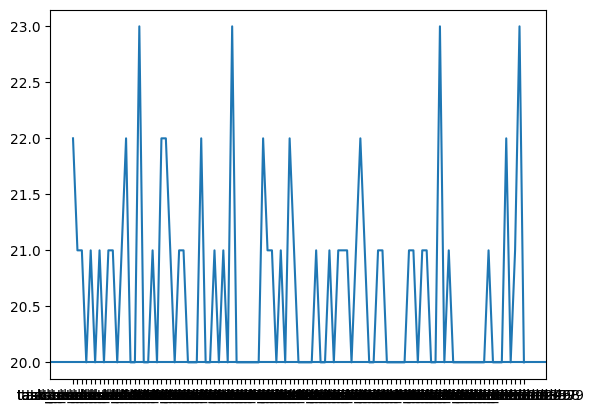

In [87]:
plt.plot(counts.index,counts)
plt.axhline(20)

In [88]:
stims = []
for k,v in nplot.tdt_dat_dict.items():
    evcs = v.epocs.SMa1.data
    stims.extend([c for c in evcs if c > 101])

In [89]:
vals, counts = np.unique(stims,return_counts=True)

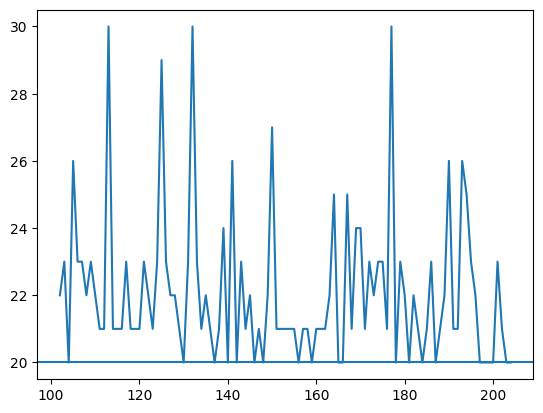

In [90]:
plt.plot(vals,counts)
plt.axhline(20)